Sample Shape: (9999, 12)
Class Distribution:
loan_status
0    0.781878
1    0.218122
Name: proportion, dtype: float64

Final Split → Train: 5999 | Val: 2000 | Test: 2000
Running Monte Carlo (50 iterations) with Train/Val/Test...

Simulation 1/50
Simulation 10/50
Simulation 20/50
Simulation 30/50
Simulation 40/50
Simulation 50/50

MONTE CARLO RESULTS - TRAIN | VALIDATION | TEST PERFORMANCE
                                    F1           AUROC             MCC  \
                                  mean     std    mean     std    mean   
Model               Set                                                  
Decision Tree       Test        0.7077  0.0127  0.8178  0.0078  0.6239   
                    Train       1.0000  0.0000  1.0000  0.0000  1.0000   
                    Validation  0.7102  0.0185  0.8189  0.0128  0.6275   
Gradient Boosting   Test        0.7752  0.0065  0.9084  0.0029  0.7317   
                    Train       0.8424  0.0049  0.9595  0.0023  0.8145   
                

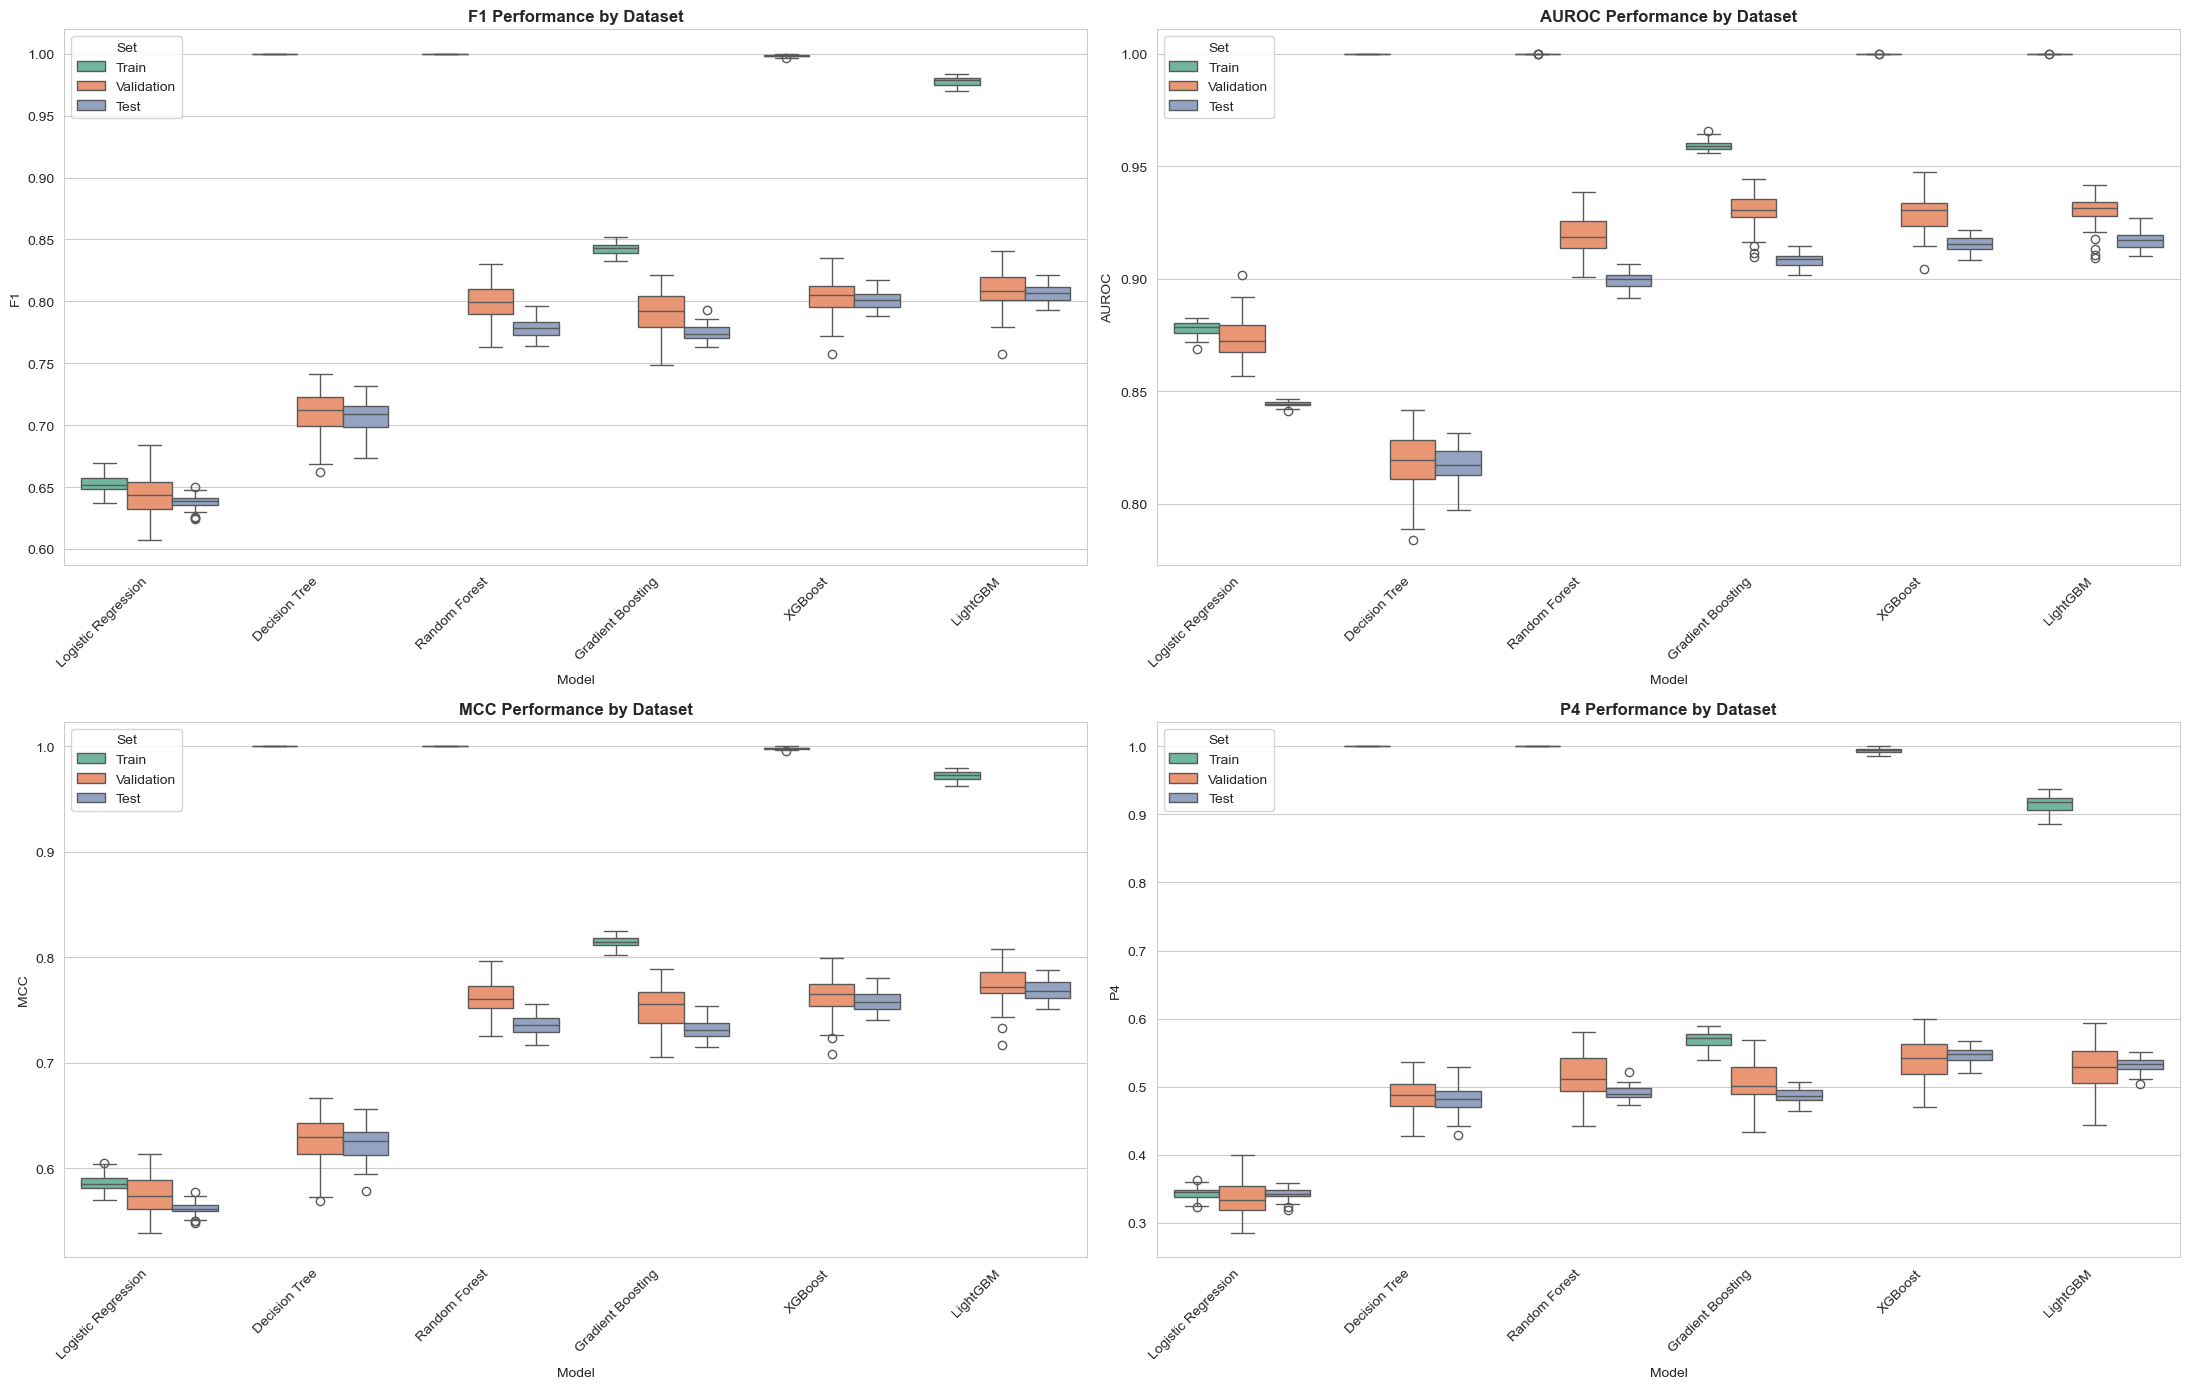

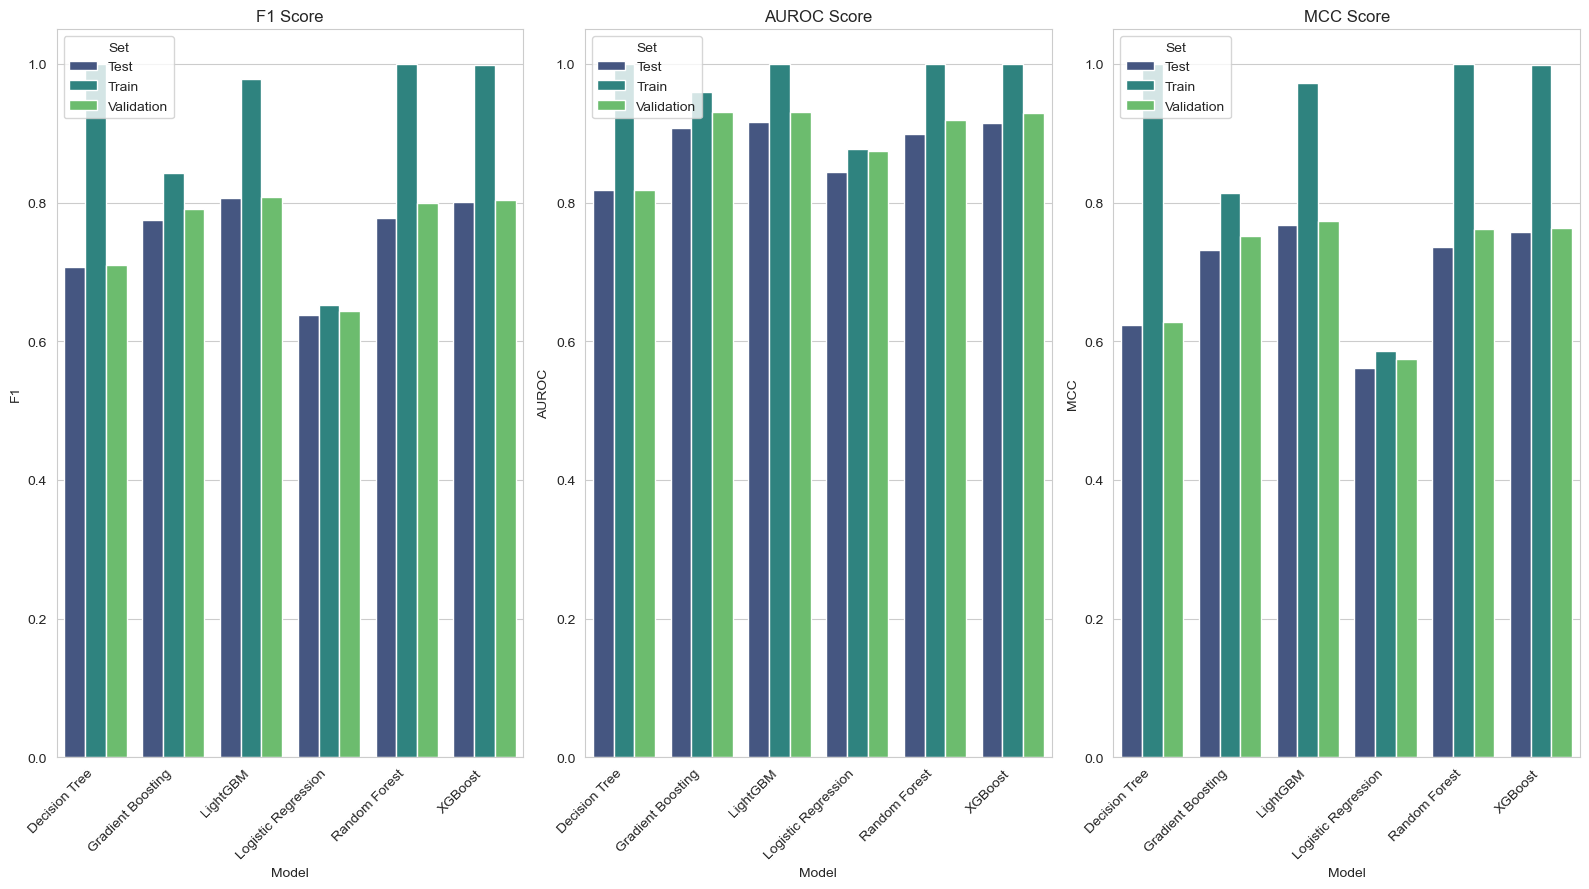

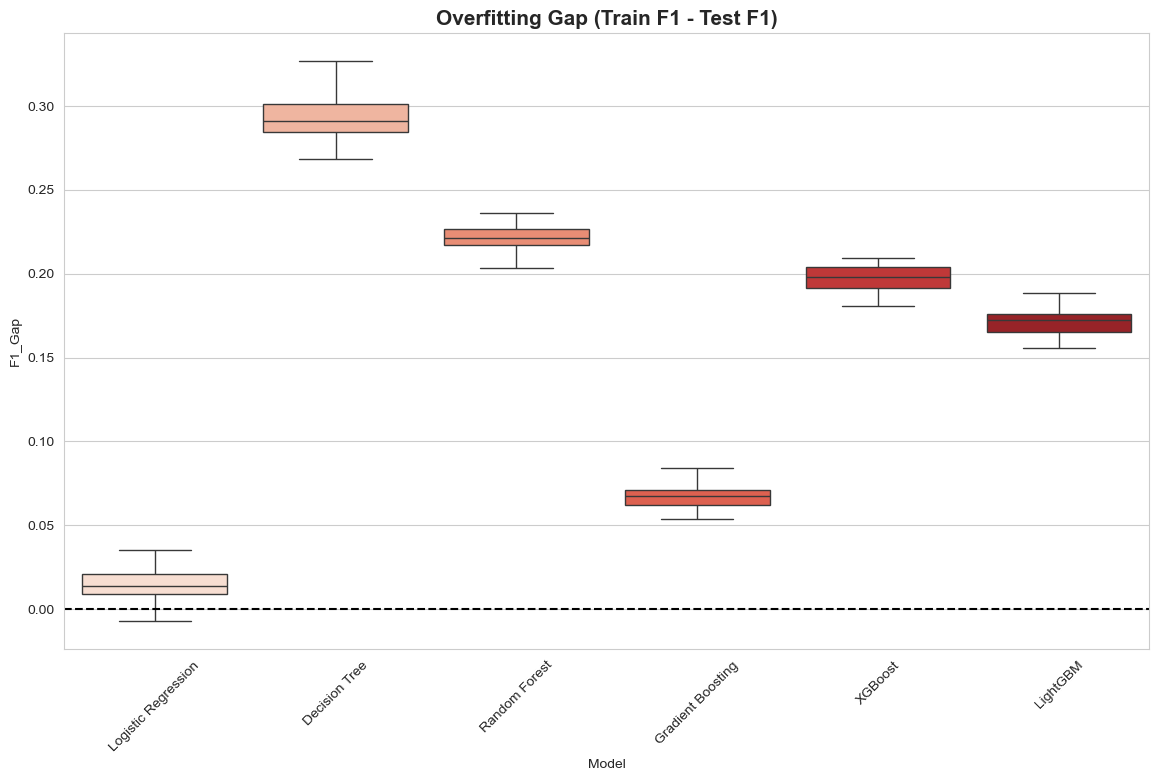


🎉 Full analysis with Train/Val/Test performance completed!


In [1]:
# =====================================================
# CREDIT RISK - MONTE CARLO WITH TRAIN / VAL / TEST PERFORMANCE
# 10,000 Stratified Sample + 3-Way Split Analysis
# =====================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from math import pi

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, roc_auc_score
)

# ------------------- 1. LOAD & SAMPLE DATA -------------------
df_original = pd.read_csv('credit_risk_dataset.csv')
target = 'loan_status'

sample_size = 10000
df_sample = df_original.groupby(target, group_keys=False).apply(
    lambda x: x.sample(n=int(sample_size * len(x) / len(df_original)), random_state=42)
)
df = df_sample.sample(n=sample_size, random_state=42) if len(df_sample) > sample_size else df_sample

print(f"Sample Shape: {df.shape}")
print(f"Class Distribution:\n{df[target].value_counts(normalize=True)}")

# ------------------- 2. FIXED 3-WAY SPLIT -------------------
X = df.drop(columns=[target])
y = df[target]

# Train (60%) | Temp (40%)
X_train_full, X_temp, y_train_full, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42)

# Validation (20%) + Test (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"\nFinal Split → Train: {len(X_train_full)} | Val: {len(X_val)} | Test: {len(X_test)}")

# ------------------- 3. PREPROCESSOR & MODELS -------------------
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.drop(target, errors='ignore').tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), 
                      ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))]), categorical_features)
])

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=150, random_state=42, eval_metric='auc', verbosity=0),
    'LightGBM': LGBMClassifier(n_estimators=150, random_state=42, verbose=-1)
}

# ------------------- 4. METRICS -------------------
def p4_measure(y_true, y_pred):
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    return prec * rec * (1 - abs(prec - rec))

def evaluate_model(y_true, y_pred, y_prob=None):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'MCC': matthews_corrcoef(y_true, y_pred),
        'P4': p4_measure(y_true, y_pred),
    }
    if y_prob is not None:
        metrics['AUROC'] = roc_auc_score(y_true, y_prob)
    return metrics

# ------------------- 5. MONTE CARLO WITH TRAIN/VAL/TEST -------------------
def monte_carlo_simulation(n_sim=50):
    results = []
    print(f"Running Monte Carlo ({n_sim} iterations) with Train/Val/Test...\n")
    
    for i in range(n_sim):
        if (i + 1) % 10 == 0 or i == 0:
            print(f"Simulation {i+1}/{n_sim}")
        
        # Repeated split on training data for Monte Carlo
        X_train, X_val_mc, y_train, y_val_mc = train_test_split(
            X_train_full, y_train_full, test_size=0.25, stratify=y_train_full, random_state=42 + i
        )
        
        # Preprocess
        X_train_prep = preprocessor.fit_transform(X_train)
        X_val_prep = preprocessor.transform(X_val_mc)
        X_test_prep = preprocessor.transform(X_test)
        
        for model_name, model in models.items():
            model.fit(X_train_prep, y_train)
            
            # === TRAINING PERFORMANCE ===
            y_pred_train = model.predict(X_train_prep)
            y_prob_train = model.predict_proba(X_train_prep)[:, 1] if hasattr(model, "predict_proba") else None
            train_metrics = evaluate_model(y_train, y_pred_train, y_prob_train)
            train_metrics['Model'] = model_name
            train_metrics['Simulation'] = i + 1
            train_metrics['Set'] = 'Train'
            results.append(train_metrics)
            
            # === VALIDATION PERFORMANCE ===
            y_pred_val = model.predict(X_val_prep)
            y_prob_val = model.predict_proba(X_val_prep)[:, 1] if hasattr(model, "predict_proba") else None
            val_metrics = evaluate_model(y_val_mc, y_pred_val, y_prob_val)
            val_metrics['Model'] = model_name
            val_metrics['Simulation'] = i + 1
            val_metrics['Set'] = 'Validation'
            results.append(val_metrics)
            
            # === TEST PERFORMANCE ===
            y_pred_test = model.predict(X_test_prep)
            y_prob_test = model.predict_proba(X_test_prep)[:, 1] if hasattr(model, "predict_proba") else None
            test_metrics = evaluate_model(y_test, y_pred_test, y_prob_test)
            test_metrics['Model'] = model_name
            test_metrics['Simulation'] = i + 1
            test_metrics['Set'] = 'Test'
            results.append(test_metrics)
    
    return pd.DataFrame(results)

# ------------------- 6. RUN SIMULATION -------------------
results_df = monte_carlo_simulation(n_sim=50)

# ------------------- 7. SUMMARY -------------------
summary = results_df.groupby(['Model', 'Set']).agg({
    'F1': ['mean', 'std'],
    'AUROC': ['mean', 'std'],
    'MCC': ['mean', 'std'],
    'P4': ['mean', 'std']
}).round(4)

print("\n" + "="*120)
print("MONTE CARLO RESULTS - TRAIN | VALIDATION | TEST PERFORMANCE")
print("="*120)
print(summary)

# ------------------- 8. VISUALIZATIONS -------------------
sns.set_style("whitegrid")

# 1. Boxplot by Set
metrics_to_plot = ['F1', 'AUROC', 'MCC', 'P4']
plt.figure(figsize=(22, 14))
for i, metric in enumerate(metrics_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Model', y=metric, hue='Set', data=results_df, palette="Set2")
    plt.title(f'{metric} Performance by Dataset', fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Set')

plt.tight_layout()
plt.savefig('train_val_test_boxplots_10000.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Mean Performance Comparison (Line Plot)
mean_perf = results_df.groupby(['Model', 'Set'])[['F1', 'AUROC', 'MCC']].mean().reset_index()

plt.figure(figsize=(16, 9))
for metric in ['F1', 'AUROC', 'MCC']:
    plt.subplot(1, 3, ['F1','AUROC','MCC'].index(metric)+1)
    sns.barplot(x='Model', y=metric, hue='Set', data=mean_perf, palette="viridis")
    plt.title(f'{metric} Score')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Set')

plt.tight_layout()
plt.savefig('train_val_test_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Overfitting Gap (Train - Test)
gap = results_df[results_df['Set'] == 'Train'].copy()
gap = gap.merge(results_df[results_df['Set'] == 'Test'], on=['Model', 'Simulation'], suffixes=('_train', '_test'))
gap['F1_Gap'] = gap['F1_train'] - gap['F1_test']

plt.figure(figsize=(14, 8))
sns.boxplot(x='Model', y='F1_Gap', data=gap, palette="Reds")
plt.title('Overfitting Gap (Train F1 - Test F1)', fontsize=15, fontweight='bold')
plt.xticks(rotation=45)
plt.axhline(0, color='black', linestyle='--')
plt.savefig('overfitting_gap.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------- 9. SAVE RESULTS -------------------
results_df.to_csv('monte_carlo_results_train_val_test_10000.csv', index=False)
summary.to_csv('summary_train_val_test_10000.csv')

print("\n🎉 Full analysis with Train/Val/Test performance completed!")

Loading dataset...
✅ Sample Shape: (9999, 12)
Class Distribution:
loan_status
0    0.781878
1    0.218122
Name: proportion, dtype: float64

Split Sizes → Train: 5999 | Val: 2000 | Test: 2000

🚀 Running Monte Carlo Simulation (40 iterations)...

Simulation 1/40
Simulation 10/40
Simulation 20/40
Simulation 30/40
Simulation 40/40

SUMMARY - TRAIN | VALIDATION | TEST PERFORMANCE
                                    F1           AUROC             MCC  \
                                  mean     std    mean     std    mean   
Model               Set                                                  
Decision Tree       Test        0.7075  0.0118  0.8176  0.0075  0.6236   
                    Train       1.0000  0.0000  1.0000  0.0000  1.0000   
                    Validation  0.7118  0.0173  0.8198  0.0117  0.6295   
Gradient Boosting   Test        0.7752  0.0063  0.9081  0.0028  0.7317   
                    Train       0.8423  0.0049  0.9594  0.0020  0.8143   
                    Validation

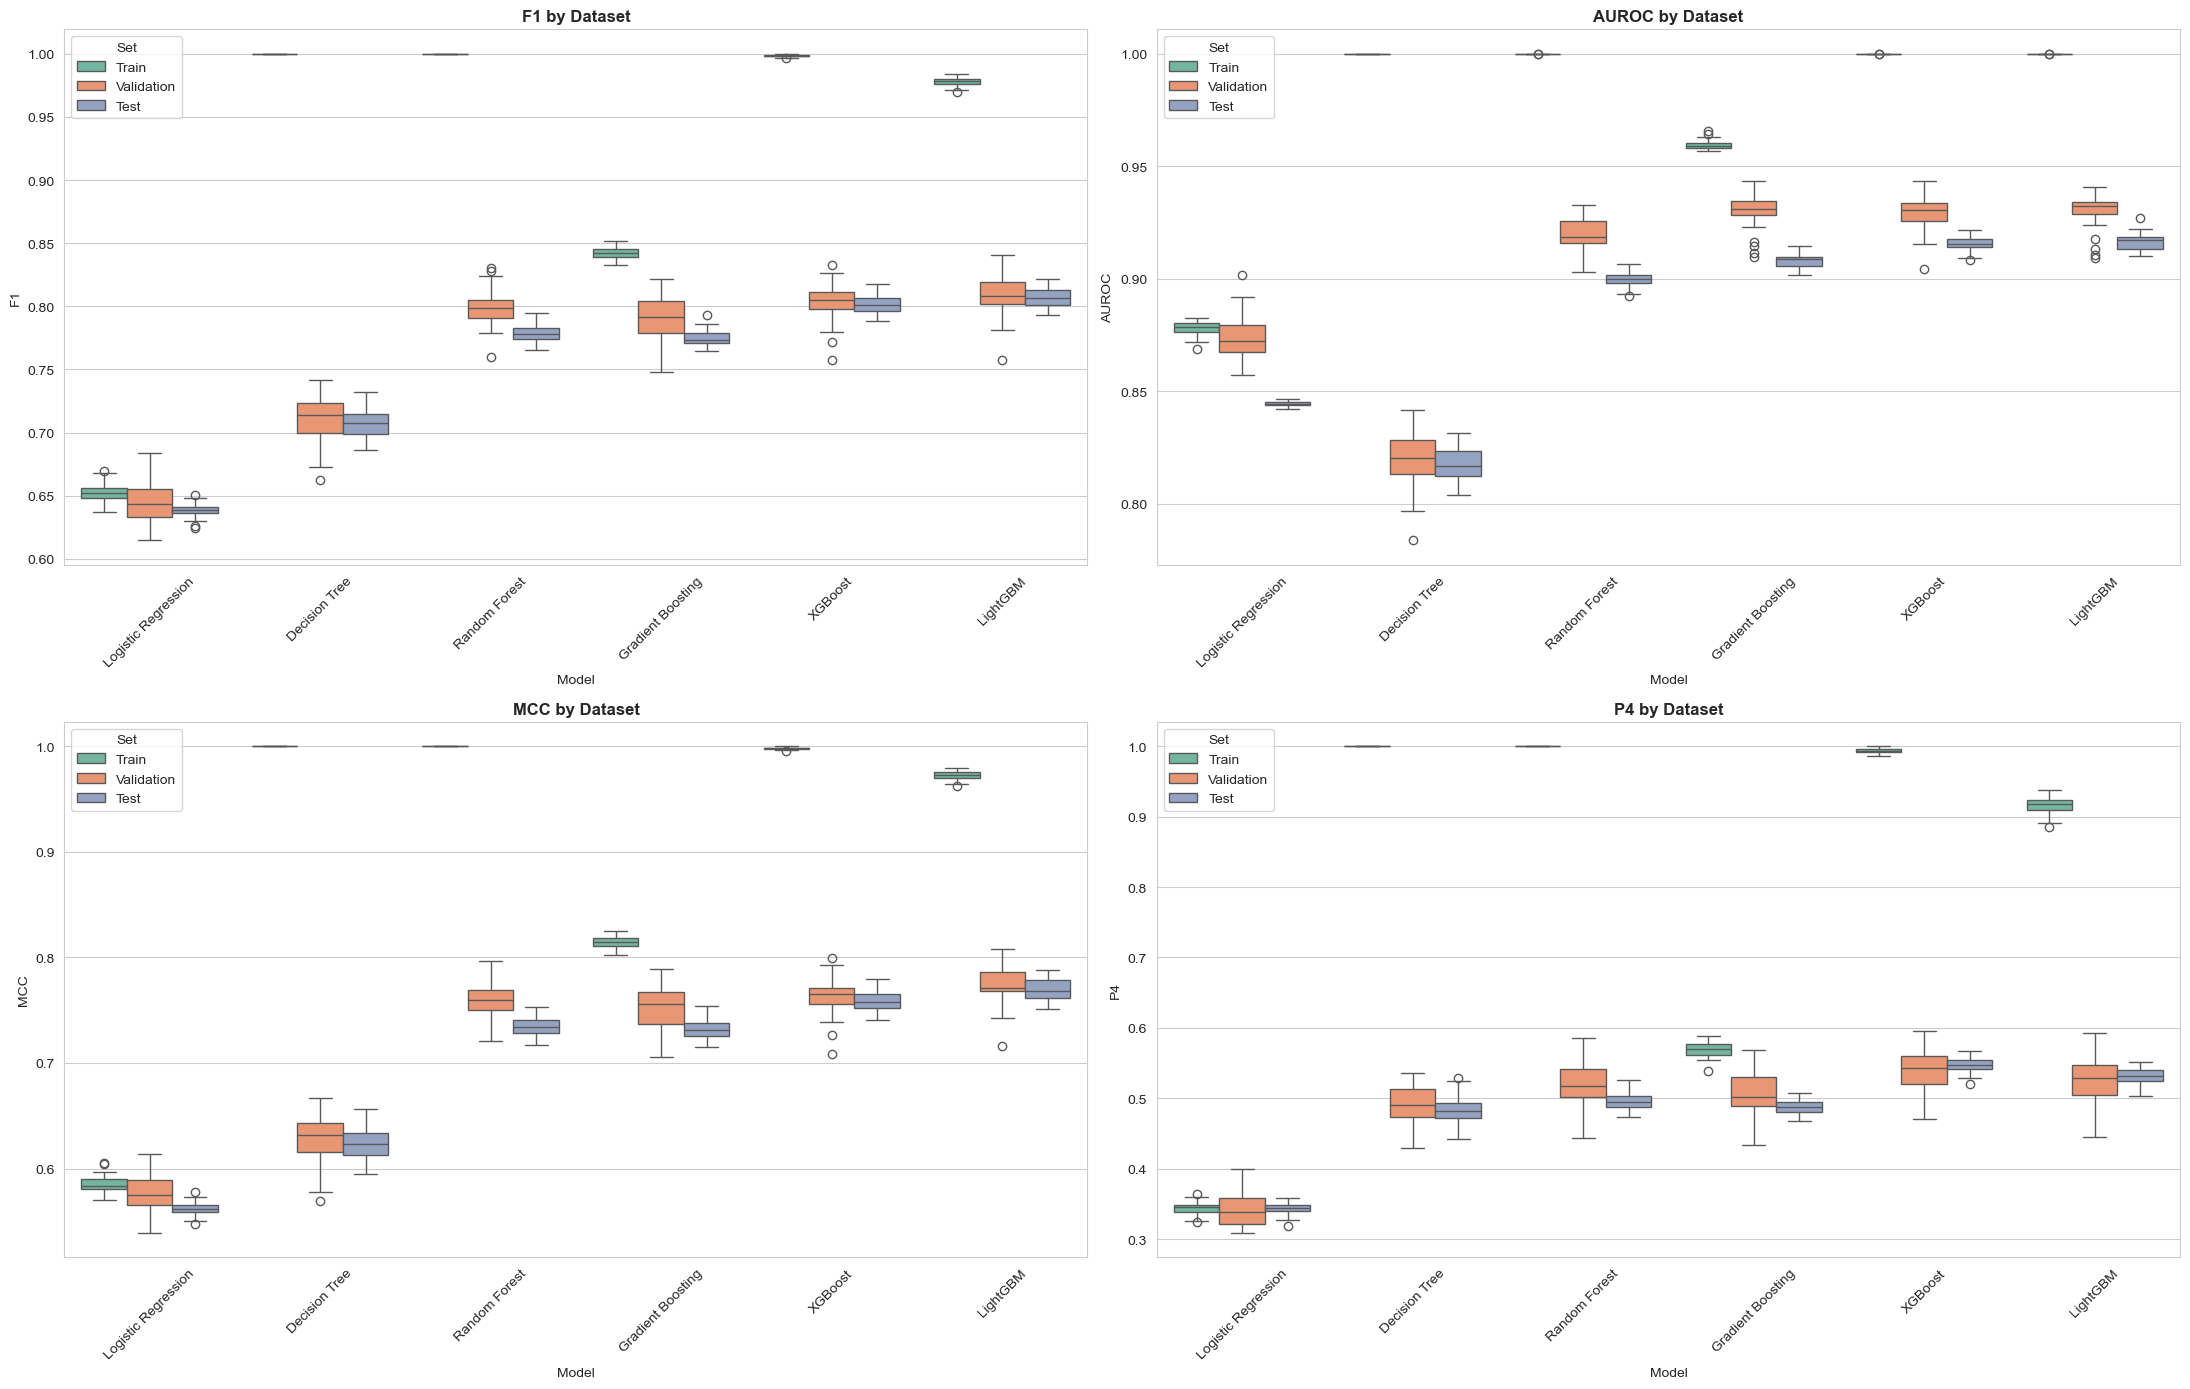

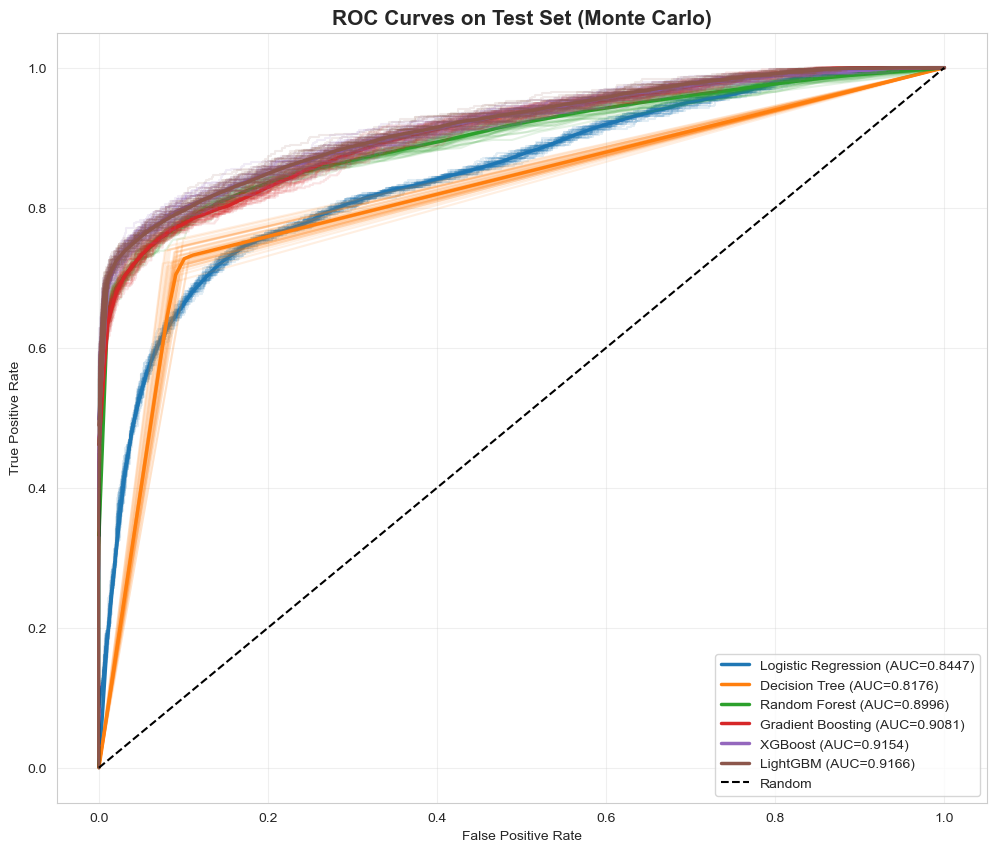

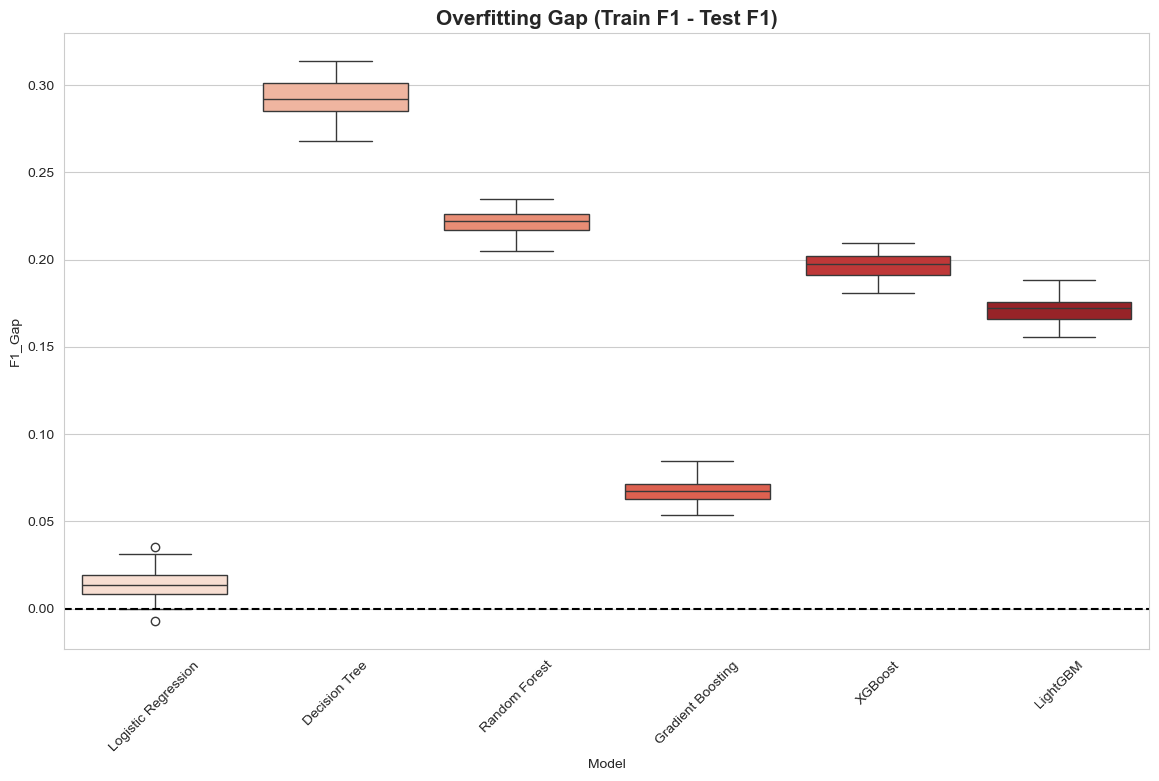


🎉 Complete Analysis Finished!
Files saved:
- monte_carlo_results_train_val_test_10000.csv
- summary_train_val_test_10000.csv
- ROC_curves_test_set.png
- boxplots_train_val_test.png
- overfitting_gap.png


In [2]:
# =====================================================
# FINAL CREDIT RISK ANALYSIS SCRIPT
# 10,000 Stratified Sample + Train/Val/Test + Monte Carlo + ROC Curves
# =====================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
from sklearn.metrics import roc_curve, auc

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, roc_auc_score
)

# ------------------- 1. LOAD DATA & CREATE 10k STRATIFIED SAMPLE -------------------
print("Loading dataset...")
df_original = pd.read_csv('credit_risk_dataset.csv')
target = 'loan_status'

sample_size = 10000
df_sample = df_original.groupby(target, group_keys=False).apply(
    lambda x: x.sample(n=int(sample_size * len(x) / len(df_original)), random_state=42)
)
df = df_sample.sample(n=sample_size, random_state=42) if len(df_sample) > sample_size else df_sample

print(f"✅ Sample Shape: {df.shape}")
print(f"Class Distribution:\n{df[target].value_counts(normalize=True)}")

# ------------------- 2. 3-WAY SPLIT -------------------
X = df.drop(columns=[target])
y = df[target]

X_train_full, X_temp, y_train_full, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"\nSplit Sizes → Train: {len(X_train_full)} | Val: {len(X_val)} | Test: {len(X_test)}")

# ------------------- 3. PREPROCESSING -------------------
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.drop(target, errors='ignore').tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), 
                      ('scaler', StandardScaler())]), numeric_features),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), 
                      ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))]), categorical_features)
])

# ------------------- 4. MODELS -------------------
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=150, random_state=42, eval_metric='auc', verbosity=0),
    'LightGBM': LGBMClassifier(n_estimators=150, random_state=42, verbose=-1)
}

# ------------------- 5. METRICS -------------------
def p4_measure(y_true, y_pred):
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    return prec * rec * (1 - abs(prec - rec))

def evaluate_model(y_true, y_pred, y_prob=None):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'MCC': matthews_corrcoef(y_true, y_pred),
        'P4': p4_measure(y_true, y_pred),
    }
    if y_prob is not None:
        metrics['AUROC'] = roc_auc_score(y_true, y_prob)
    return metrics

# ------------------- 6. MONTE CARLO SIMULATION (Train/Val/Test + ROC) -------------------
def monte_carlo_simulation(n_sim=40):
    results = []
    roc_data = []
    
    print(f"\n🚀 Running Monte Carlo Simulation ({n_sim} iterations)...\n")
    
    for i in range(n_sim):
        if (i + 1) % 10 == 0 or i == 0:
            print(f"Simulation {i+1}/{n_sim}")
        
        # Repeated split on training data
        X_train, X_val_mc, y_train, y_val_mc = train_test_split(
            X_train_full, y_train_full, test_size=0.25, stratify=y_train_full, random_state=42 + i
        )
        
        X_train_prep = preprocessor.fit_transform(X_train)
        X_val_prep = preprocessor.transform(X_val_mc)
        X_test_prep = preprocessor.transform(X_test)
        
        for model_name, model in models.items():
            model.fit(X_train_prep, y_train)
            
            for set_name, X_set, y_true in [
                ('Train', X_train_prep, y_train),
                ('Validation', X_val_prep, y_val_mc),
                ('Test', X_test_prep, y_test)
            ]:
                y_prob = model.predict_proba(X_set)[:, 1] if hasattr(model, "predict_proba") else None
                y_pred = (y_prob >= 0.5).astype(int)
                
                metrics = evaluate_model(y_true, y_pred, y_prob)
                metrics['Model'] = model_name
                metrics['Simulation'] = i + 1
                metrics['Set'] = set_name
                results.append(metrics)
            
            # Save ROC data for Test set
            if y_prob is not None and set_name == 'Test':
                fpr, tpr, _ = roc_curve(y_test, y_prob)
                roc_data.append({
                    'Model': model_name,
                    'Simulation': i + 1,
                    'fpr': fpr,
                    'tpr': tpr,
                    'auc': auc(fpr, tpr)
                })
    
    return pd.DataFrame(results), pd.DataFrame(roc_data)

# ------------------- 7. RUN ANALYSIS -------------------
results_df, roc_df = monte_carlo_simulation(n_sim=40)

# Summary
summary = results_df.groupby(['Model', 'Set']).agg({
    'F1': ['mean', 'std'],
    'AUROC': ['mean', 'std'],
    'MCC': ['mean', 'std'],
    'P4': ['mean', 'std']
}).round(4)

print("\n" + "="*110)
print("SUMMARY - TRAIN | VALIDATION | TEST PERFORMANCE")
print("="*110)
print(summary)

# ------------------- 8. VISUALIZATIONS -------------------
sns.set_style("whitegrid")

# 1. Boxplots by Set
metrics_list = ['F1', 'AUROC', 'MCC', 'P4']
plt.figure(figsize=(22, 14))
for i, metric in enumerate(metrics_list, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Model', y=metric, hue='Set', data=results_df, palette="Set2")
    plt.title(f'{metric} by Dataset', fontweight='bold')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('boxplots_train_val_test.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. ROC Curves (Test Set)
plt.figure(figsize=(12, 10))
models_list = results_df['Model'].unique()
colors = sns.color_palette("tab10")

for idx, model_name in enumerate(models_list):
    model_roc = roc_df[roc_df['Model'] == model_name]
    mean_auc = model_roc['auc'].mean()
    
    # Plot individual curves lightly
    for _, row in model_roc.iterrows():
        plt.plot(row['fpr'], row['tpr'], alpha=0.12, color=colors[idx])
    
    # Plot average ROC
    mean_fpr = np.linspace(0, 1, 100)
    mean_tpr = np.mean([np.interp(mean_fpr, row['fpr'], row['tpr']) for _, row in model_roc.iterrows()], axis=0)
    plt.plot(mean_fpr, mean_tpr, label=f'{model_name} (AUC={mean_auc:.4f})', linewidth=2.5, color=colors[idx])

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves on Test Set (Monte Carlo)', fontsize=15, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('ROC_curves_test_set.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Overfitting Gap
train_df = results_df[results_df['Set'] == 'Train']
test_df = results_df[results_df['Set'] == 'Test']
gap = train_df.merge(test_df, on=['Model', 'Simulation'], suffixes=('_train', '_test'))
gap['F1_Gap'] = gap['F1_train'] - gap['F1_test']

plt.figure(figsize=(14, 8))
sns.boxplot(x='Model', y='F1_Gap', data=gap, palette="Reds")
plt.title('Overfitting Gap (Train F1 - Test F1)', fontsize=15, fontweight='bold')
plt.axhline(0, color='black', linestyle='--')
plt.xticks(rotation=45)
plt.savefig('overfitting_gap.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------- 9. SAVE RESULTS -------------------
results_df.to_csv('monte_carlo_results_train_val_test_10000.csv', index=False)
summary.to_csv('summary_train_val_test_10000.csv')

print("\n🎉 Complete Analysis Finished!")
print("Files saved:")
print("- monte_carlo_results_train_val_test_10000.csv")
print("- summary_train_val_test_10000.csv")
print("- ROC_curves_test_set.png")
print("- boxplots_train_val_test.png")
print("- overfitting_gap.png")